##Project Title: **A Hybrid GA and PSO Optimized Approach for Heart-Disease Prediction**
###**Intermediate Project**

------------------------------------------------
By: Salman Hussain & Amit Raj


------------------------------------------------

In [15]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
import time as tm

In [16]:
#Load and preprocess dataset
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
cleveland_df = pd.read_csv("Heart_disease_cleveland_new.csv")
cleveland_df.columns = columns
cleveland_df['target'] = (cleveland_df['target'] > 0).astype(int)

#Validate class counts
cleveland_class_counts = cleveland_df['target'].value_counts().sort_index()

#Normalize using MinMaxScaler
scaler = MinMaxScaler()
cleveland_df[columns[:-1]] = scaler.fit_transform(cleveland_df[columns[:-1]])

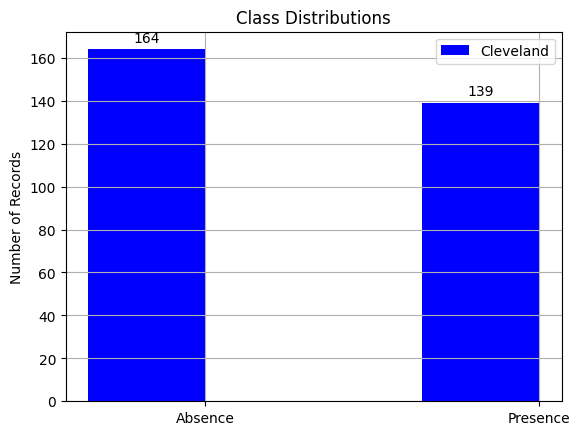

In [17]:
#Class Distribution
labels = ['Absence', 'Presence']
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, [cleveland_class_counts[0], cleveland_class_counts[1]], width, label='Cleveland', color='blue')
ax.set_ylabel('Number of Records')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for bar in bar1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.title("Class Distributions")
plt.grid(True)
plt.show()

In [18]:
#Statistical Analysis & Feature Importance Evaluation
def summary_stats(df):
    stats_1 = df[df['target'] == 1].describe().T[['mean', 'std']]
    stats_0 = df[df['target'] == 0].describe().T[['mean', 'std']]
    return stats_1, stats_0
cleveland_stats_1, cleveland_stats_0 = summary_stats(cleveland_df)
print("Stats (Target = 1) ===")
print("Cleveland:")
print(cleveland_stats_1)
print(" Stats (Target = 0) ===")
print("Cleveland:")
print(cleveland_stats_0)

Stats (Target = 1) ===
Cleveland:
              mean       std
age       0.575540  0.165384
sex       0.820144  0.385457
cp        0.863309  0.274560
trestbps  0.382720  0.177066
chol      0.286472  0.112984
fbs       0.158273  0.366317
restecg   0.586331  0.488743
thalach   0.521061  0.172467
exang     0.546763  0.499609
oldpeak   0.253887  0.210094
slope     0.413669  0.281868
ca        0.376499  0.340111
thal      0.683453  0.442915
target    1.000000  0.000000
 Stats (Target = 0) ===
Cleveland:
              mean       std
age       0.491362  0.198166
sex       0.560976  0.497788
cp        0.597561  0.305540
trestbps  0.332547  0.152875
chol      0.266302  0.122047
fbs       0.140244  0.348303
restecg   0.417683  0.493135
thalach   0.667008  0.146558
exang     0.140244  0.348303
oldpeak   0.094611  0.126086
slope     0.204268  0.297299
ca        0.089431  0.209188
thal      0.189024  0.380831
target    0.000000  0.000000


In [19]:
#T² Metric Calculation to evaluate feature discriminative power
def compute_t2(df):
    df1 = df[df['target'] == 1]
    df0 = df[df['target'] == 0]
    n1, n0 = len(df1), len(df0)
    t2_data = []
    for col in df.columns[:-1]:
        x1, s1 = df1[col].mean(), df1[col].std()
        x0, s0 = df0[col].mean(), df0[col].std()
        sp = (((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2))
        t2 = ((x1 - x0) ** 2) / (sp * (1 / n1 + 1 / n0)) if sp > 0 else 0
        t2_data.append((col, sp, x1 - x0, t2))
    return pd.DataFrame(t2_data, columns=['Feature', 'Sp', 'Delta', 'T2']).sort_values(by='T2', ascending=False)

cleveland_t2 = compute_t2(cleveland_df)
print("\nT² Metric for Cleveland:")
print(cleveland_t2)

#Correlation analysis
cleveland_corr = cleveland_df[['cp', 'slope', 'ca', 'thal', 'exang']].corr()
print("\nCorrelation (Cleveland):")
print(cleveland_corr)


T² Metric for Cleveland:
     Feature        Sp     Delta          T2
12      thal  0.168479  0.494429  109.163583
11        ca  0.076731  0.287068   80.800610
8      exang  0.180134  0.406519   69.020891
9    oldpeak  0.028846  0.159277   66.166707
7    thalach  0.025269 -0.145947   63.419223
2         cp  0.085115  0.265748   62.423779
10     slope  0.084289  0.209401   39.138194
1        sex  0.202305  0.259168   24.978872
0        age  0.033806  0.084178   15.769637
6    restecg  0.241205  0.168648    8.871394
3   trestbps  0.027030  0.050173    7.006632
4       chol  0.013919  0.020170    2.199054
5        fbs  0.127217  0.018029    0.192237

Correlation (Cleveland):
             cp     slope        ca      thal     exang
cp     1.000000  0.152050  0.233117  0.259835  0.384060
slope  0.152050  1.000000  0.110803  0.267540  0.257748
ca     0.233117  0.110803  1.000000  0.247557  0.145788
thal   0.259835  0.267540  0.247557  1.000000  0.321680
exang  0.384060  0.257748  0.145788  0

In [20]:
# Hybrid Feature Selection using GAPSO

#Genetic Algorithm (GA) Components
def initialize_population(size, n):
    #Each chromosome is a binary string of length n
    return np.random.randint(0, 2, size=(size, n))

def crossover(p1, p2):
    #Single-point crossover
    mask = np.random.rand(len(p1)) > 0.5
    return np.where(mask, p1, p2)

def mutate(chrom, mutation_probs):
    #Mutate each gene based on its corresponding mutation probability
    for i in range(len(chrom)):
        if np.random.rand() < mutation_probs[i]:
            chrom[i] = 1 - chrom[i]
    return chrom

def fitness_fn(X, y, chrom):
    #If no feature is selected, fitness is zero.
    if np.sum(chrom) == 0:
        return 0
    #Select features based on chromosome binary string
    features = X.columns[chrom == 1]
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    #Use cross-validation (3-fold) to estimate performance
    scores = cross_val_score(model, X[features], y, cv=3, scoring='accuracy')
    return np.mean(scores)

In [21]:
#Particle Swarm Optimization (PSO) Components
class Particle:
    def __init__(self, position):
        self.position = position
        self.velocity = np.zeros_like(position)
        self.best_position = position.copy()
        self.best_fitness = -np.inf

def initialize_swarm(size, n):
    #Initialize a list of particles each with a random binary position
    return [Particle(initialize_population(1, n)[0]) for _ in range(size)]

def update_velocity(particle, global_best, w=0.7, c1=1.5, c2=1.5):
    #Update velocity based on personal best and global best
    r1, r2 = np.random.rand(2)
    cognitive = c1 * r1 * (particle.best_position - particle.position)
    social = c2 * r2 * (global_best - particle.position)
    particle.velocity = w * particle.velocity + cognitive + social

def update_position(particle, mutation_probs):
    #Use a sigmoid function to update position probabilistically
    sigmoid_velocity = 1 / (1 + np.exp(-particle.velocity))
    particle.position = np.where(np.random.rand(len(particle.position)) < sigmoid_velocity,
                                 1 - particle.position,
                                 particle.position)
    #Apply mutation to further refine the particles feature subset
    particle.position = mutate(particle.position, mutation_probs)

In [22]:
#GAPSO Algorithm
def run_gapso(X, y, t2_scores, gens=10, pop_size=10, dataset_name=""):
    n = X.shape[1]
    #identify top features
    top_features = t2_scores['Feature'][:4].tolist()
    mutation_probs = np.array([0.001 if f in top_features else 0.1 for f in X.columns])

    #Initialize two subpopulations: GA population and PSO swarm
    ga_pop = initialize_population(pop_size // 2, n)
    swarm = initialize_swarm(pop_size // 2, n)

    best_fitness_log = []
    best_chromosome = None
    global_best_position = None
    global_best_fitness = -np.inf

    for gen in range(gens):
        #GA Evaluation
        ga_scores = np.array([fitness_fn(X, y, chrom) for chrom in ga_pop])
        #Identify the best chromosome in GA population
        ga_best_idx = np.argmax(ga_scores)

        #PSO Evaluation
        for particle in swarm:
            current_fitness = fitness_fn(X, y, particle.position)
            #Update particles personal best
            if current_fitness > particle.best_fitness:
                particle.best_fitness = current_fitness
                particle.best_position = particle.position.copy()
            #Update global best from swarm
            if current_fitness > global_best_fitness:
                global_best_fitness = current_fitness
                global_best_position = particle.position.copy()

        #Combined Best
        combined_pop = np.vstack([ga_pop, np.array([p.position for p in swarm])])
        combined_scores = np.concatenate([ga_scores, np.array([p.best_fitness for p in swarm])])
        current_best_idx = np.argmax(combined_scores)
        best_fitness_log.append(combined_scores[current_best_idx])
        if best_chromosome is None or combined_scores[current_best_idx] > fitness_fn(X, y, best_chromosome):
            best_chromosome = combined_pop[current_best_idx]

        print(f"{dataset_name} | Generation {gen+1}/{gens}, Best Fitness = {best_fitness_log[-1]:.4f}")

        #GA Operations: Selection, Crossover and Mutation
        #A simple selection: take top quarter of GA individuals
        selected = ga_pop[np.argsort(ga_scores)[-pop_size // 4:]]
        offspring = []
        #Generate offspring using crossover and mutation from selected parents
        for i in range(0, len(selected), 2):
            if i+1 < len(selected):
                child = crossover(selected[i], selected[i+1])
                offspring.append(mutate(child.copy(), mutation_probs))
        #Form new GA population by combining selected and offspring individuals
        if len(offspring) > 0:
            ga_pop = np.vstack([selected, offspring])
        else:
            ga_pop = selected

        #PSO Operations
        for particle in swarm:
            update_velocity(particle, global_best_position)
            update_position(particle, mutation_probs)

    return best_chromosome, best_fitness_log

In [23]:
#Run GAPSO feature selection on the dataset
X_c = cleveland_df.drop(columns='target')
y_c = cleveland_df['target']
best_chrom_c, fit_log_c = run_gapso(X_c, y_c, cleveland_t2, gens=10, pop_size=10, dataset_name="Cleveland")

#Display selected features from GAPSO
selected_features = X_c.columns[best_chrom_c == 1].tolist()
print("\nSelected Features - Cleveland:", selected_features)

Cleveland | Generation 1/10, Best Fitness = 0.8053
Cleveland | Generation 2/10, Best Fitness = 0.8053
Cleveland | Generation 3/10, Best Fitness = 0.8119
Cleveland | Generation 4/10, Best Fitness = 0.8119
Cleveland | Generation 5/10, Best Fitness = 0.8119
Cleveland | Generation 6/10, Best Fitness = 0.8218
Cleveland | Generation 7/10, Best Fitness = 0.8218
Cleveland | Generation 8/10, Best Fitness = 0.8218
Cleveland | Generation 9/10, Best Fitness = 0.8317
Cleveland | Generation 10/10, Best Fitness = 0.8317

Selected Features - Cleveland: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [24]:
#Model Training & Hyperparameter Optimization Using Random Forest

#Grid Search for Random Forest hyperparameters
grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt']
}
rf = RandomForestClassifier(random_state=42)

def run_grid_search(X, y):
    clf = GridSearchCV(rf, grid_params, scoring='accuracy', cv=5, n_jobs=-1)
    clf.fit(X, y)
    return clf.best_estimator_, clf.best_params_, clf.best_score_

#Run grid search on the subset of features selected by GAPSO
best_rf_c, best_params_c, best_score_c = run_grid_search(X_c[selected_features], y_c)
results = list(best_params_c.items()) + [("RF Accuracy", best_score_c)]
results_df = pd.DataFrame(results, columns=["Parameter", "Value"])
print("\nRF Best Params & Accuracy by Grid Search")
print(results_df.to_string(index=False))


RF Best Params & Accuracy by Grid Search
        Parameter     Value
        max_depth         5
     max_features      sqrt
 min_samples_leaf         1
min_samples_split         5
     n_estimators        50
      RF Accuracy  0.861148


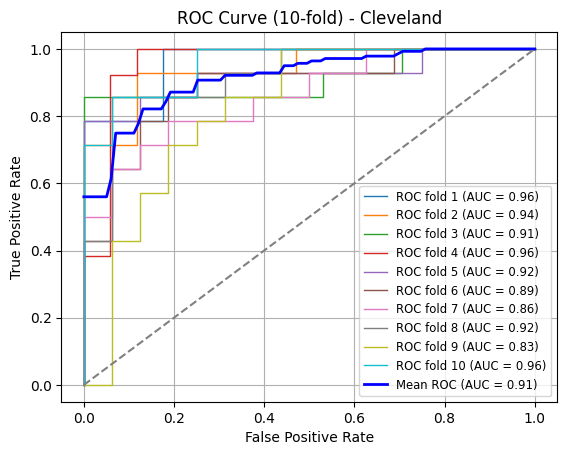

In [25]:

#Performance Evaluation

#ROC Curve using 10-fold cross-validation
def plot_roc_10fold(model, X, y, fig_title):
    cv = StratifiedKFold(n_splits=10)
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)
    aucs = []
    plt.figure()
    for i, (train, test) in enumerate(cv.split(X, y)):
        model.fit(X.iloc[train], y.iloc[train])
        probas_ = model.predict_proba(X.iloc[test])
        fpr, tpr, _ = roc_curve(y.iloc[test], probas_[:, 1])
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, lw=1, label=f'ROC fold {i+1} (AUC = {roc_auc:.2f})')

    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, color='blue', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(fig_title)
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.show()

plot_roc_10fold(best_rf_c, X_c[selected_features], y_c, "ROC Curve (10-fold) - Cleveland")

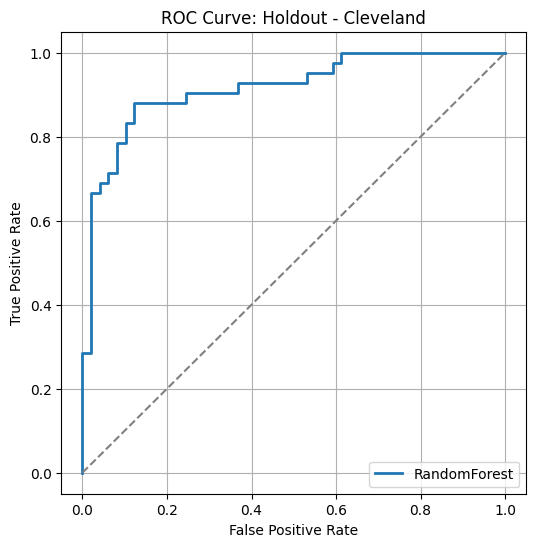

In [26]:
#ROC Curve Plot using train_test_split
def plot_roc_holdout(model, X, y, label):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label='RandomForest', lw=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {label}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
plot_roc_holdout(best_rf_c, X_c[selected_features], y_c, label="Holdout - Cleveland")

In [27]:
#Compare multiple classifiers on the selected features
def compare_models(X, y):
    models = {
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'DecisionTree': DecisionTreeClassifier(random_state=42),
        'NaiveBayes': GaussianNB(),
        'SVM': SVC(probability=True, random_state=42)
    }
    records = []
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
        records.append({"Model": name, "Mean Accuracy": np.mean(scores), "Std Dev": np.std(scores)})
    return pd.DataFrame(records)

print("\nCleveland Classifier Comparison on Selected Features:")
print(compare_models(X_c[selected_features], y_c).to_string(index=False))


Cleveland Classifier Comparison on Selected Features:
       Model  Mean Accuracy  Std Dev
RandomForest       0.844194 0.067596
DecisionTree       0.761505 0.104293
  NaiveBayes       0.808280 0.047495
         SVM       0.818280 0.065861
